In [1]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
import re

import os
from tqdm import tqdm 

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_act import ADModel_act
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [2]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

In [30]:
simple_model_results = pd.read_csv('results/results_simple_act_test_LeakyReLU.csv')
simple_model_results_bootstrap = pd.read_csv('results/results_simple_bootstraps_LeakyReLU.csv')
simple_model_results_bootstrap['bootstrap_number'] = [int(re.search("BOOTSTRAP_(\d+)", model.removeprefix("../../"))[1]) for model in  simple_model_results_bootstrap["model_name"]]

# two_model_results = pd.read_csv('results/results_two_state_test_leakyrelu.csv')
# two_model_results['abund_k'] = [int(re.search(r'ak(\d+)',model).group(1)) for model in two_model_results['model_name']]
# shuffled_results = pd.read_csv('results/results_simple_shuffles.csv')
# shuffled_results['shuffle_number'] = [int(re.search("SHUFFLE_(\d+)", model.removeprefix("../../"))[1]) for model in  shuffled_results["model_name"]]
# shuffled_results_act = shuffled_results[shuffled_results['model_type'] == "simple_act"]


In [4]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
# relu = True
outchannel = 1

# Function to read in weights
def load_model_get_weights(row, layer1='conv1.weight', layer2="linear1.weight", two_state=False): 
    # print(two_state)
    model = row["model_name"].removeprefix("../../")
    kernel_size = row["kernel_size"]

    if two_state: 
        abund_k_two = row["abund_k"]
        activity_fun = row["activity_fun"]
        loaded_model = ADModel_two_state_abund(size,activity_fun, kernel_size, relu=relu, abund_k=abund_k_two)
    else: 
        loaded_model = ADModel_act(size, kernel_size)
    loaded_model.load_state_dict(torch.load(f"{model}.pth"))

    loaded_model.eval()
    model_state_dict = loaded_model.state_dict()
    width = model_state_dict[layer1].shape[0] * model_state_dict[layer1].shape[2]
    conv_weight = model_state_dict[layer1].detach().numpy().reshape(width,20)

    linear_weights_size = (40 - kernel_size + 1)
    linear_weights = model_state_dict[layer2].detach().numpy().reshape(linear_weights_size)
    # print(linear_weights)

    return loaded_model, conv_weight, linear_weights

def get_weights_array(results_table, k_size, num_shuffles=25, num_seeds=30, two_state=False):
    results_table = results_table.copy()
    # Creating arrays to save weights
    conv_weight_arr = np.zeros((num_shuffles, num_seeds, k_size, 20))
    linear_weight_arr = np.zeros((num_shuffles, num_seeds, (40 - k_size + 1)))

    # If there is more than one shuffle (i.e. not real weights), sort by shuffle number
    if num_shuffles > 1:
        results_table = results_table.sort_values("bootstrap_number").reset_index()

    i = 0
    
    # Loop through each row in the table and load weights
    for index in tqdm(results_table[results_table['kernel_size'] == k_size].index):
        row = results_table.loc[index]
        model = row["model_name"].removeprefix("../../")
        
        if num_shuffles > 1:    
            shuffle_number = row['bootstrap_number']
        else:
            shuffle_number = 1
        
        if shuffle_number > num_shuffles:
            break

        _, weights, linear_weights = load_model_get_weights(row, two_state=two_state)

        conv_weight_arr[shuffle_number -1, i, :, :] = weights #.reshape(100, )
        linear_weight_arr[shuffle_number - 1, i, :] = linear_weights

        if i < num_seeds - 1: 
            i +=1 
        else:
            i = 0
    
    return conv_weight_arr, linear_weight_arr

# Need to define our test statistics

# A. Cosine similarity between weights
def cosine_similarity(shuffled_conv_arr, real_conv_arr, real_linear_arr):
    num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
    # aa_num = 1

    num_iterations = int(num_seeds * (num_seeds-1) / 2)
    shuffle_cos_similarities = np.zeros((num_shuffles, num_iterations, aa_nums))
    

    for aa in range(aa_nums): 
        for shuffle_num in range(num_shuffles):
            a = 0
            for i in range(num_seeds - 1):
                for j in range(i+1, num_seeds):
                    vector1 = shuffled_conv_arr[shuffle_num, i, :, aa]#.flatten()
                    vector2 = shuffled_conv_arr[shuffle_num, j, :, aa]#.flatten()
                    
                    sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
                    shuffle_cos_similarities[shuffle_num, a, aa] = sim
                    a += 1


    similarities_real = np.zeros((1, 435, aa_nums))

    # Which seeds had negative weights
    neg_weight_filter = (real_linear_arr > 0).all(axis=2)

    # Options: Flip sign or analyze separately
    real_conv_arr_flipped = real_conv_arr.copy()
    real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]

    for aa in range(aa_nums): 
        a=0
        for i in range(num_seeds - 1):
            for j in range(i+1, num_seeds):
                vector1 = real_conv_arr_flipped[0, i, :, aa] #.flatten()
                vector2 = real_conv_arr_flipped[0, j, :, aa] #.flatten()
                
                sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
                similarities_real[0, a, aa] = sim
                a+=1
        
    return shuffle_cos_similarities, similarities_real


# B. Sum of weights
def weight_sum(shuffled_conv_arr, real_conv_arr, real_linear_arr):
    num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
    # aa_num = 1

    shuffled_row_sums = shuffled_conv_arr[:, :, :, :].sum(axis=2)

    # Which seeds had negative weights
    neg_weight_filter = (real_linear_arr > 0).all(axis=2)
    print(neg_weight_filter)

    # Options: Flip sign or analyze separately
    real_conv_arr_flipped = real_conv_arr.copy()
    real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]
    shuffled_real_sums = real_conv_arr_flipped[:, :, :, :].sum(axis=2)

    return shuffled_row_sums, shuffled_real_sums


# TO DO: ADD in negative weight filters
def make_boxplot(shuffle_test_stat_arr, real_test_stat_arr, rows, cols, aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"] ):
    
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    fig, axs = plt.subplots(rows, cols, figsize=(10*cols, 4*rows))

    row_idx = 0
    col_idx = 0

    if rows > 1: 
        for i in range(0, len(aa_order)):

            axs[row_idx, col_idx].boxplot(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T)

            axs[row_idx, col_idx].boxplot(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T, positions=[26], 
                                        widths=1.0, patch_artist=True, boxprops=dict(facecolor='lightblue'))

            vals = real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].flatten()
            jitter = np.random.normal(0, 0.04, size=len(vals))
            axs[row_idx, col_idx].scatter(
                np.full(len(vals), 26) + jitter,
                vals,
                s=18,
                alpha=0.7,
                color='black',
                zorder=4
            )

            axs[row_idx, col_idx].set_xlabel(aa_order[i], fontsize=20)

            axs[row_idx, col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

            row_idx += 1
            if row_idx == rows:
                row_idx = 0
                col_idx += 1
    else:
        for i in range(0, len(aa_order)):

            axs[col_idx].boxplot(shuffle_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T)

            axs[col_idx].boxplot(real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].T, positions=[26], 
                                        widths=1.0, patch_artist=True, boxprops=dict(facecolor='lightblue'))
            
            vals = real_test_stat_arr[:, :, orig_aa_order.index(aa_order[i])].flatten()
            jitter = np.random.normal(0, 0.04, size=len(vals))
            axs[col_idx].scatter(
                np.full(len(vals), 26) + jitter,
                vals,
                s=18,
                alpha=0.7,
                color='black',
                zorder=4
            )

            axs[col_idx].set_xlabel(aa_order[i], fontsize=20)

            axs[col_idx].set_xticks(range(0, 26, 2), range(0, 26, 2))

            col_idx += 1
    

def p_val_greater_than(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle > sum_real.min(axis=1).reshape(1, 1, 20)).sum(axis=0).sum(axis=0) / (sum_shuffle.shape[0] * sum_shuffle.shape[1])
    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)

    print("min p-val:", 1/(sum_shuffle.shape[0] * sum_shuffle.shape[1]))
    
    return p_val

def p_val_greater_than_mean(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle.mean(axis=1) > sum_real.mean(axis=1).reshape(1, 20)).sum(axis=0) / sum_shuffle.shape[0]
    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)

    print("min p-val:", 1/(sum_shuffle.shape[0]))
    
    return p_val


def p_val_less_than(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle < sum_real.max(axis=1).reshape(1, 1, 20)).sum(axis=0).sum(axis=0) / (sum_shuffle.shape[0] * sum_shuffle.shape[1])
    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)
    
    print("min p-val:", 1/(sum_shuffle.shape[0] * sum_shuffle.shape[1]))
    
    return p_val

def p_val_less_than_mean(sum_shuffle, sum_real):
    orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    p_val = (sum_shuffle.mean(axis=1) < sum_real.mean(axis=1).reshape(1, 20)).sum(axis=0) / sum_shuffle.shape[0]

    for aa, val in zip(orig_aa_order, p_val):
        print(aa, ":", val)

    print("min p-val:", 1/(sum_shuffle.shape[0]))
    
    return p_val

In [31]:
bootstrap_conv_arr, bootstrap_linear_arr = get_weights_array(simple_model_results_bootstrap, k_size=30, num_shuffles=200, num_seeds=1, two_state=False)

100%|██████████| 200/200 [00:00<00:00, 1010.33it/s]


In [32]:
conv_arr, linear_arr = get_weights_array(simple_model_results, k_size=30, num_shuffles=1, num_seeds=30, two_state=False)

100%|██████████| 30/30 [00:10<00:00,  2.86it/s]


In [35]:
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

def get_conv_weights(model, layer): 
    """
    Extracts the convolutional layer weights and
    returns them as a pandas dataframe
    """
    model_state_dict = model.state_dict()
    width = model_state_dict[layer].shape[0] * model_state_dict[layer].shape[2]
    conv_weight = model_state_dict[layer].detach().numpy().reshape(width,20)
    conv_weights = pd.DataFrame(conv_weight,columns = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"])
    conv_weights = conv_weights[amino_acids]
    return conv_weights

In [36]:
# This is setting up our colors for the plots

# Colors for convolutional filter
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Blue, White, Red
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Colors for AA labels
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

In [8]:
curr_aas = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

In [9]:
new_idx = []
for aa in amino_acids:
    new_idx.append(curr_aas.index(aa))

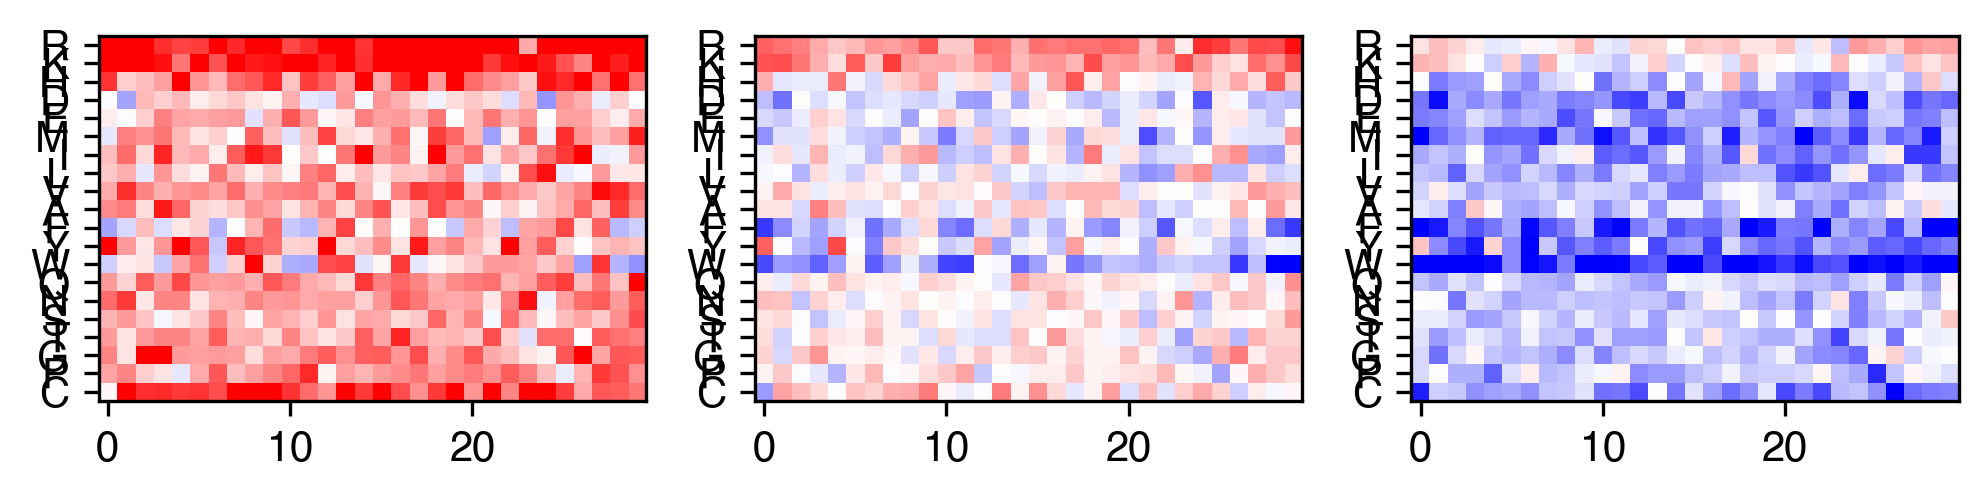

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(8, 2))

lim = np.max(np.abs(bootstrap_conv_arr.mean(axis=0)))

# Min
axs[0].imshow(np.percentile(bootstrap_conv_arr, 2.5, axis=0).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
axs[0].set_yticks(range(0, 20), amino_acids)

# Mean
axs[1].imshow(bootstrap_conv_arr.mean(axis=0).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
axs[1].set_yticks(range(0, 20), amino_acids)

# Max
axs[2].imshow(np.percentile(bootstrap_conv_arr, 97.5, axis=0).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
axs[2].set_yticks(range(0, 20), amino_acids)

# plt.colorbar()
plt.show()

In [42]:
conv_arr.shape

(1, 30, 30, 20)

In [43]:
np.mean(conv_arr, axis=1)

array([[[-0.227, -0.019, -0.207, 0.097, 0.056, -0.023, -0.022, -0.052,
         -0.019, -0.054, -0.046, -0.033, -0.047, -0.057, -0.008, 0.012,
         0.097, 0.195, 0.010, 0.188],
        [-0.167, -0.016, -0.156, 0.073, 0.024, -0.017, -0.020, -0.034,
         -0.005, -0.068, -0.029, -0.014, -0.047, -0.046, -0.039, 0.027,
         0.025, 0.160, -0.003, 0.161],
        [-0.126, -0.046, -0.122, 0.073, 0.020, 0.010, -0.027, -0.013,
         -0.037, -0.004, -0.035, 0.011, -0.025, -0.014, -0.013, 0.026,
         0.033, 0.065, -0.016, 0.161],
        [-0.130, -0.007, -0.149, 0.083, 0.009, 0.015, -0.033, 0.007,
         -0.007, -0.047, -0.030, 0.022, -0.025, -0.040, -0.027, 0.004,
         0.031, 0.103, -0.063, 0.128],
        [-0.069, -0.032, -0.137, 0.024, 0.031, -0.008, -0.017, 0.002,
         -0.022, -0.072, -0.029, 0.013, -0.028, -0.024, 0.002, 0.019,
         0.040, 0.126, 0.006, 0.120],
        [-0.098, -0.029, -0.102, 0.056, 0.019, -0.002, -0.014, -0.002,
         -0.051, -0.066, -0.0

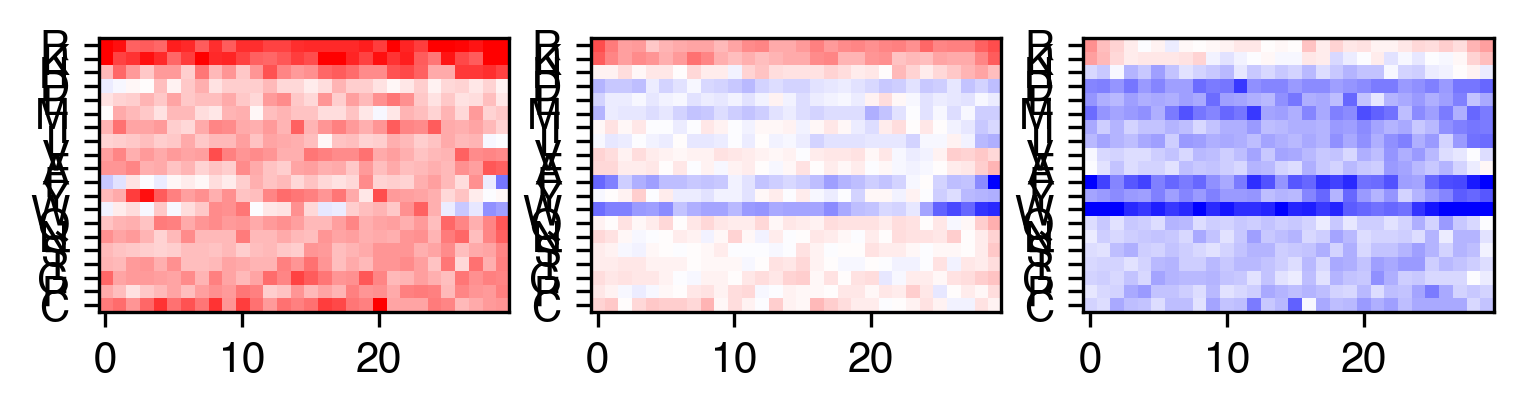

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(6, 4))

lim = np.max(np.abs(conv_arr.mean(axis=1)))

# Min
axs[0].imshow(np.percentile(conv_arr, 2.5, axis=1).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
axs[0].set_yticks(range(0, 20), amino_acids)

# Mean
axs[1].imshow(conv_arr.mean(axis=1).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
axs[1].set_yticks(range(0, 20), amino_acids)

# Max
axs[2].imshow(np.percentile(conv_arr, 97.5, axis=1).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
axs[2].set_yticks(range(0, 20), amino_acids)

# plt.colorbar()
plt.show()

In [45]:
plt.imshow(conv_arr[conv_arr[:, :, 0, -1] < 0][2], cmap=custom_cmap, vmin=-lim,vmax=lim)
plt.colorbar()

IndexError: index 2 is out of bounds for axis 0 with size 1

IndexError: index 16 is out of bounds for axis 0 with size 11

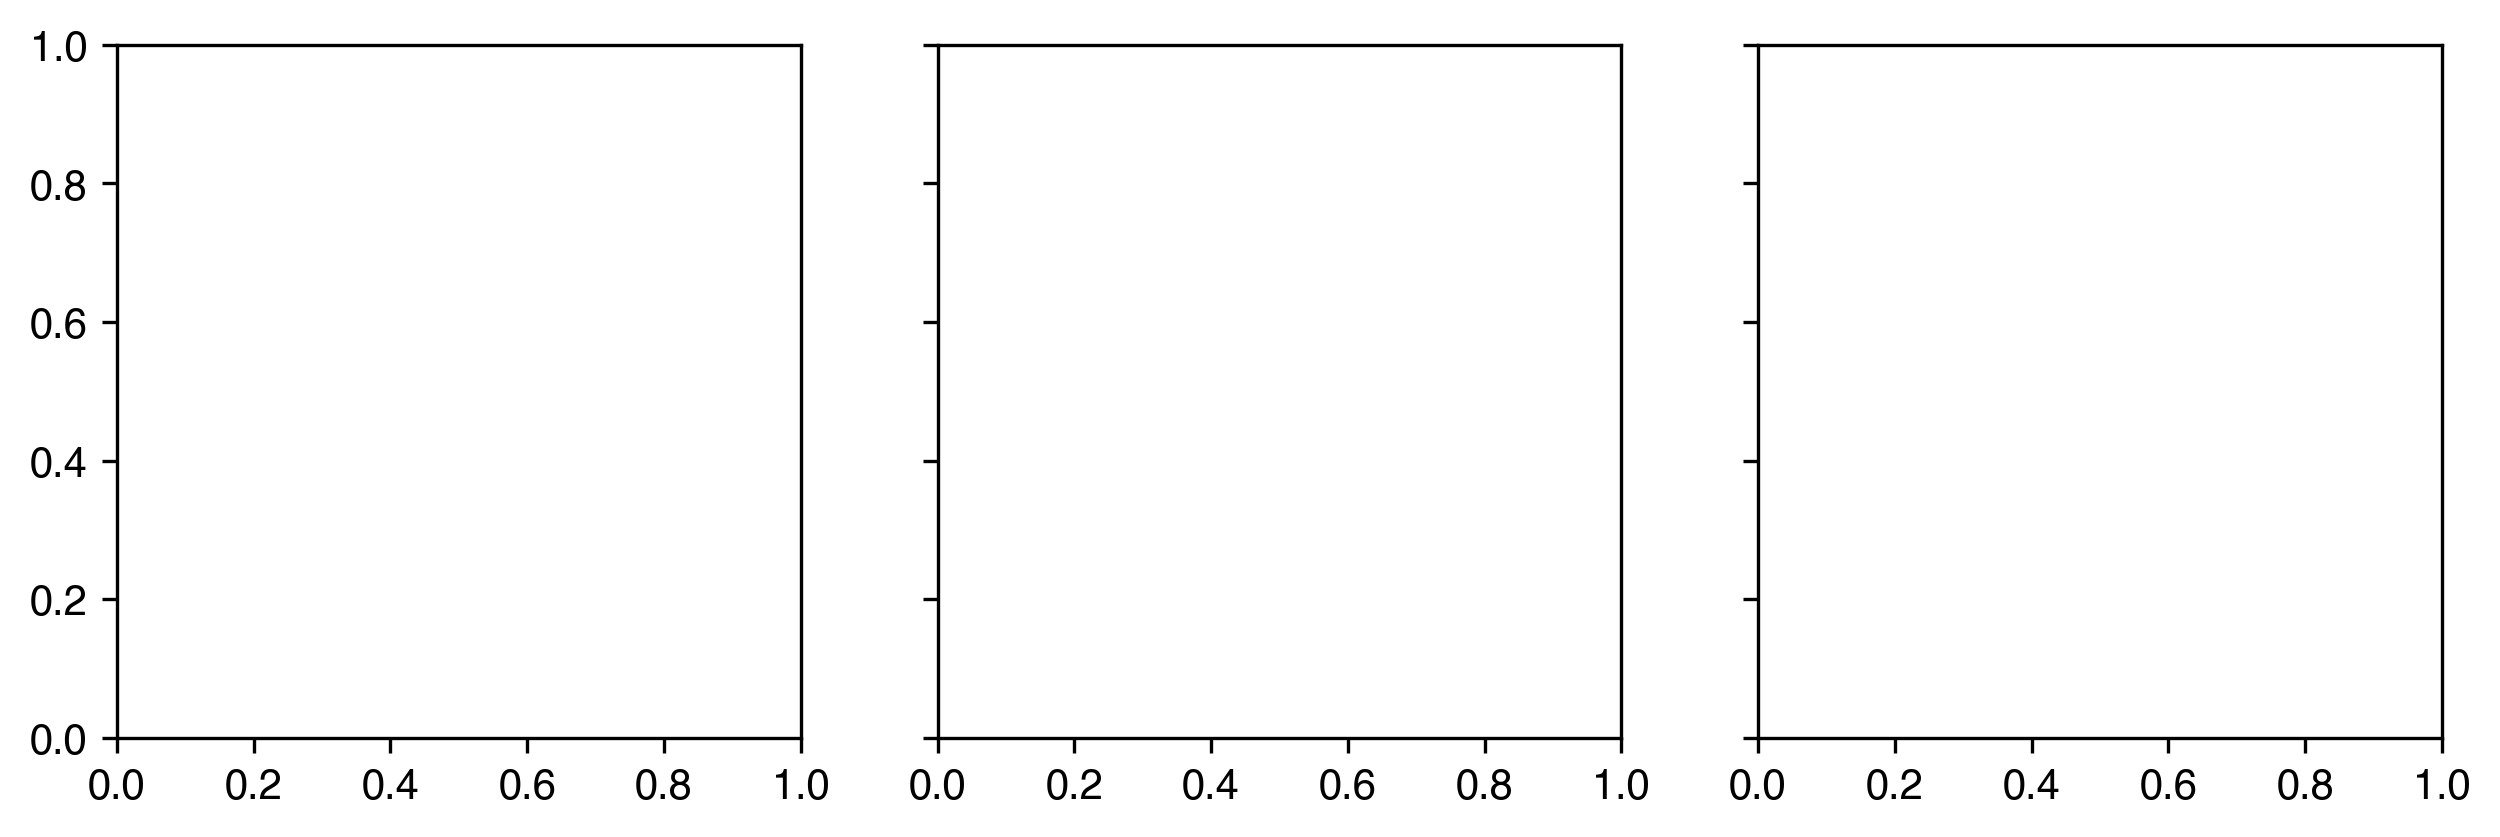

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

lim = np.max(np.abs(conv_arr.mean(axis=1)))

# Min
axs[0].bar(x=range(len(np.percentile(linear_arr, 2.5, axis=1).squeeze().T[new_idx])), height=np.percentile(linear_arr, 2.5, axis=1).squeeze().T[new_idx])

# # Mean
axs[1].bar(x=range(len(np.mean(linear_arr, axis=1).squeeze().T[new_idx])), height=np.mean(linear_arr, axis=1).squeeze().T[new_idx])

# axs[1].imshow(conv_arr.mean(axis=1).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
# axs[1].set_yticks(range(0, 20), amino_acids)

# # Max
axs[2].bar(x=range(len(np.percentile(linear_arr, 97.5, axis=1).squeeze().T[new_idx])), height=np.percentile(linear_arr, 97.5, axis=1).squeeze().T[new_idx])

# axs[2].imshow(np.percentile(conv_arr, 97.5, axis=1).squeeze().T[new_idx], cmap=custom_cmap, vmin=-lim,vmax=lim)
# axs[2].set_yticks(range(0, 20), amino_acids)

# plt.colorbar()

sns.despine()
plt.show()


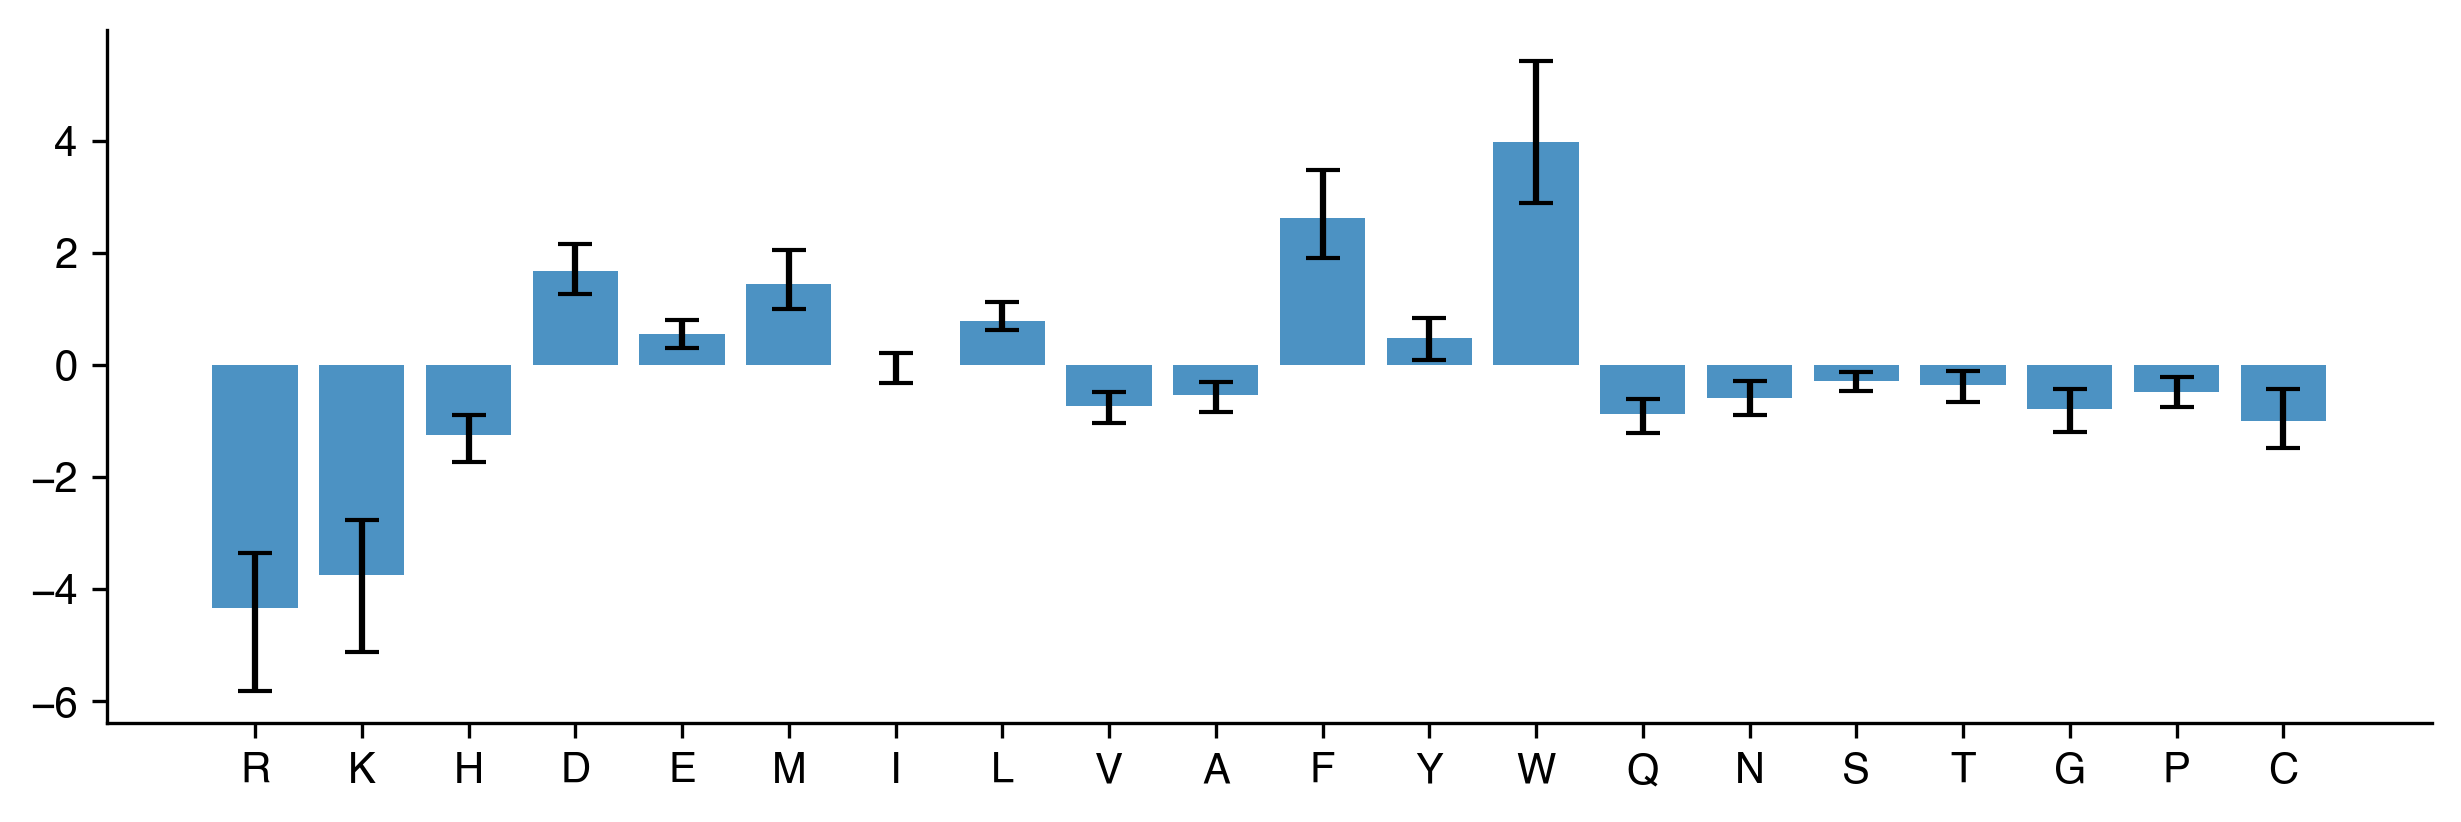

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharey=True)

# 1) compute once
summed = conv_arr.sum(axis=2)  # shape: (A, B, ...) depending on your data

# 2) compute summary stats along axis=1 (same as your code)
mu    = np.mean(summed, axis=1).squeeze().T[new_idx]
lower = np.percentile(summed,  2.5, axis=1).squeeze().T[new_idx]
upper = np.percentile(summed, 97.5, axis=1).squeeze().T[new_idx]

# 3) convert to matplotlib-style error bars: distances from mu
error_bars = np.vstack([mu - lower, upper - mu])

# optional safety (can happen from numerical issues)
error_bars = np.clip(error_bars, 0, None)

ax.bar(
    range(len(mu)),
    mu,
    yerr=error_bars,
    capsize=4,
    alpha=0.8
)



sns.despine()
plt.xticks(range(20), amino_acids)
plt.show()


In [28]:
bootstrap_conv_arr.sum(axis=2).shape

(200, 1, 20)

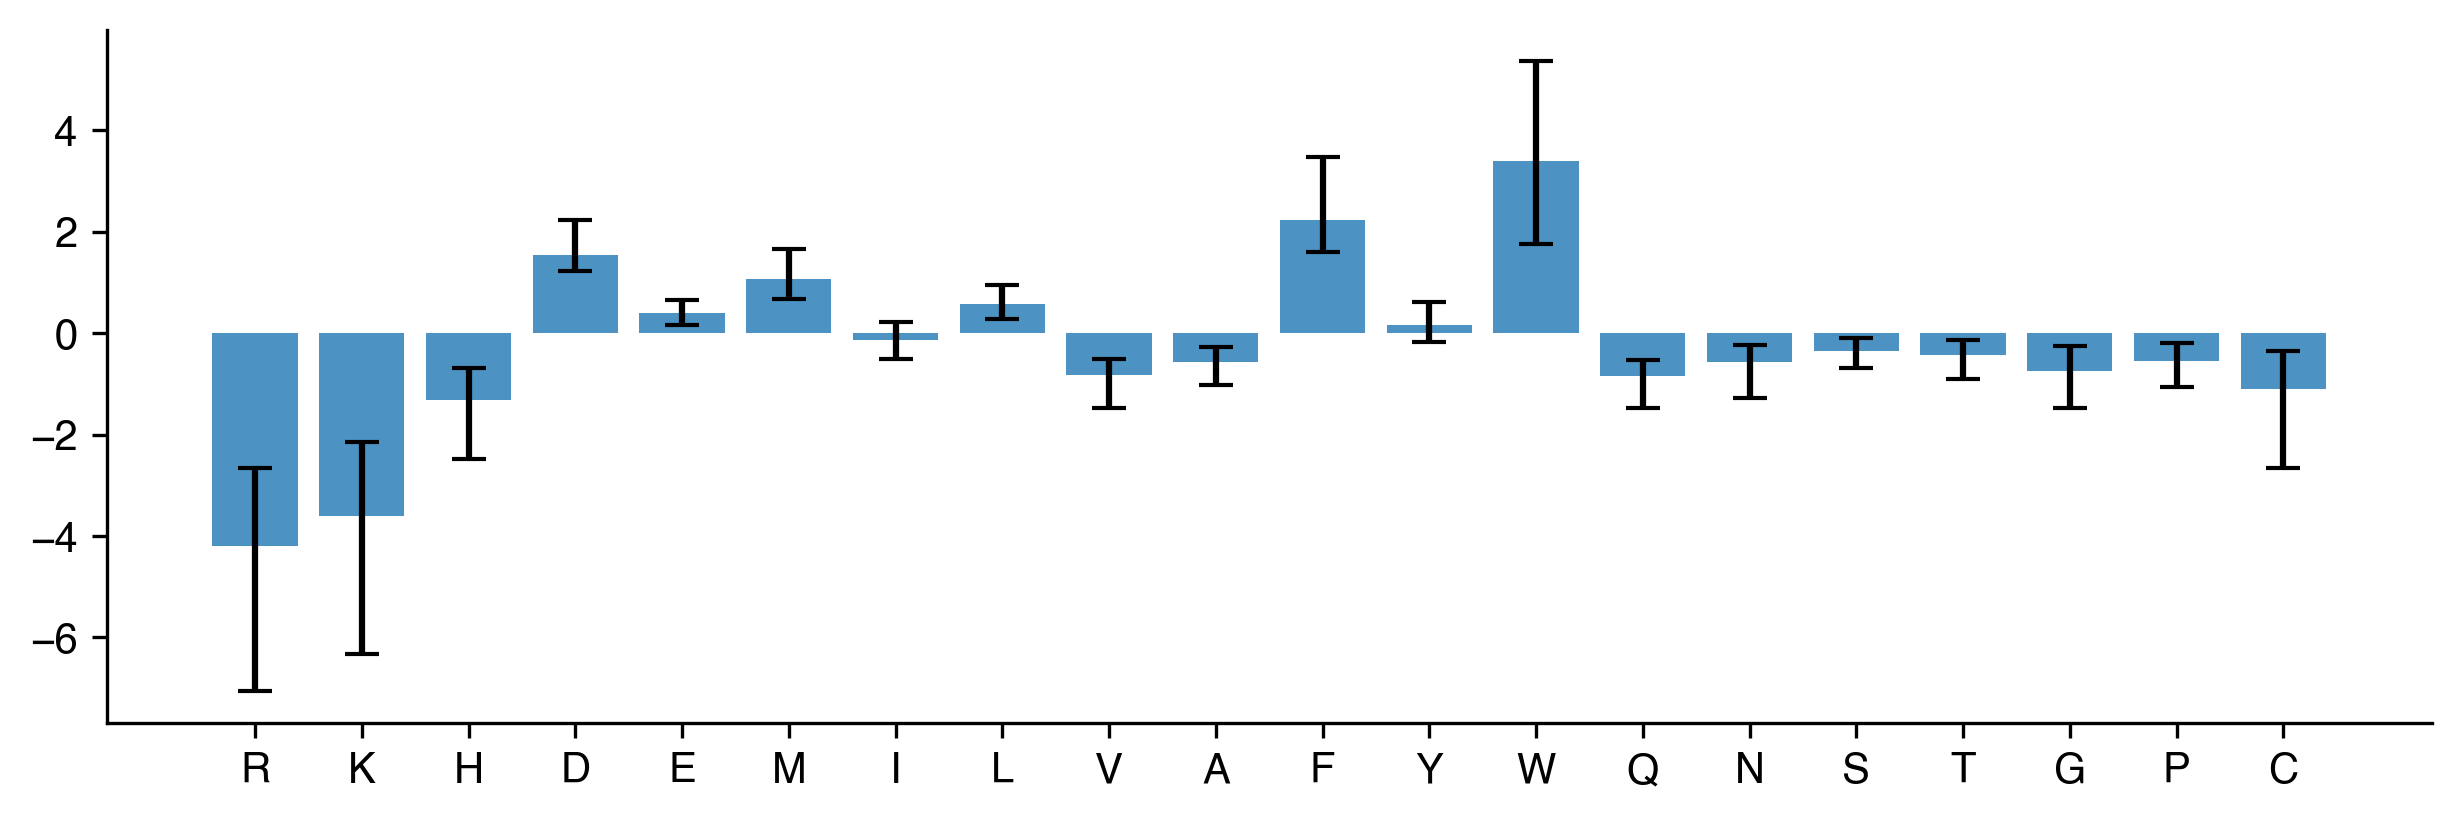

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharey=True)

# 1) compute once
summed = bootstrap_conv_arr.sum(axis=2)  # shape: (A, B, ...) depending on your data

# 2) compute summary stats along axis=1 (same as your code)
mu    = np.mean(summed, axis=0).squeeze().T[new_idx]
lower = np.percentile(summed,  2.5, axis=0).squeeze().T[new_idx]
upper = np.percentile(summed, 97.5, axis=0).squeeze().T[new_idx]

# 3) convert to matplotlib-style error bars: distances from mu
error_bars = np.vstack([mu - lower, upper - mu])

# optional safety (can happen from numerical issues)
error_bars = np.clip(error_bars, 0, None)

ax.bar(
    range(len(mu)),
    mu,
    yerr=error_bars,
    capsize=4,
    alpha=0.8
)


sns.despine()
plt.xticks(range(20), amino_acids)
plt.show()
